In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="5m8kDa8TSCpBOBWEooxK")
project = rf.workspace("aryamans-workspace-etmwn").project("vehicle-registration-plates-trudk-bof6v")
version = project.version(1)
dataset = version.download("yolov8")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 39.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 70.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 113.5 MB/s eta 0:00:0000:01
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.25.1 requires google-cloud-bigquery


Extracting Dataset Version Zip to Vehicle-Registration-Plates-1 in yolov8:: 100%|██████████| 17651/17651 [00:01<00:00, 9112.82it/s] 


In [3]:
!pip install roboflow ultralytics -q

from ultralytics import YOLO

# Train YOLOv8
model = YOLO("yolov8n.pt")  # nano = fast; use yolov8s.pt for better accuracy

model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    project="license_plate_detection",
    name="yolov8_plates",
    device=0  # GPU on Kaggle
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.2 MB/s eta 0:00:00a 0:00:01
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.37 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/Vehicle-Registration-Plates-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78ab56e6b920>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 


0: 384x640 1 License_Plate, 9.0ms
Speed: 2.1ms preprocess, 9.0ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)
Plate at [179, 317, 293, 353] | confidence: 0.67


True

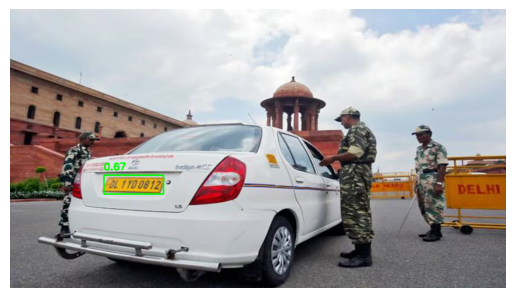

In [18]:
from ultralytics import YOLO
import cv2
from matplotlib import pyplot as plt
from PIL import Image
import numpy as np

# Load model
model = YOLO("/kaggle/working/runs/detect/license_plate_detection/yolov8_plates/weights/best.pt")

# ✅ FIXED PATH (space in folder name)
img_path = "/kaggle/input/datasets/a0ry1m1n/image-vehicle/hsrp_660_120618040959.avif"

# Read image using PIL
img = np.array(Image.open(img_path).convert("RGB"))

# Run inference
results = model(img)

# Process results
for result in results:
    for box in result.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf = box.conf[0].item()

        print(f"Plate at [{x1:.0f}, {y1:.0f}, {x2:.0f}, {y2:.0f}] | confidence: {conf:.2f}")

        # Draw box
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img, f"{conf:.2f}", (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)

# Show image
plt.imshow(img)
plt.axis('off')

# Save output
cv2.imwrite("/kaggle/working/output.jpg", cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

In [6]:
import os

for root, dirs, files in os.walk("/kaggle/working"):
    for f in files:
        if f.endswith(".pt"):
            print(os.path.join(root, f))

/kaggle/working/yolo26n.pt
/kaggle/working/yolov8n.pt
/kaggle/working/runs/detect/license_plate_detection/yolov8_plates/weights/last.pt
/kaggle/working/runs/detect/license_plate_detection/yolov8_plates/weights/best.pt
